In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparams
epochs = 30
batch_size = 100
learning_rate = 0.001

# image preprocessing modules
transform = transforms.Compose([transforms.Pad(4),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomCrop(32),
                                transforms.ToTensor()])

# cifar10 dataset loader 
train_dataset = torchvision.datasets.CIFAR10(root = '../../data/',
                                             train=True,
                                             transform = transform,
                                             download = True)
test_dataset = torchvision.datasets.CIFAR10(root = '../../data/',
                                            train = False,
                                            transform = transforms.ToTensor())

# data loader

train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = batch_size,
                                           shuffle = True)
test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = batch_size,
                                          shuffle = False)

100.0%


Extracting ../../data/cifar-10-python.tar.gz to ../../data/


In [11]:
def conv3x3(in_channels, out_channels, stride = 1) :
    return nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = stride, padding = 1, bias = False)

class ResidualBlock(nn.Module) : 
    def __init__(self,in_channels,out_channels, stride = 1, downsampling = None) :
        super(ResidualBlock,self).__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace = True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsampling

    def forward(self,x) : 
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample :
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

In [12]:
class ResNet(nn.Module) :
    def __init__(self,block,layers,num_classes = 10) : 
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3,16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace = True)
        self.layer1 = self.make_layer(block,16, layers[0], stride = 1)
        self.layer2 = self.make_layer(block,32, layers[1], stride = 2)
        self.layer3 = self.make_layer(block,64, layers[2], stride = 2)
        self.avg_pool = nn.AvgPool2d(8)
        self.fc = nn.Linear(64,num_classes)
    def make_layer(self, block, out_channels, blocks, stride = 1) :
        downsample = None
        if (self.in_channels != out_channels) or stride != 1 : 
            downsample = nn.Sequential(conv3x3(self.in_channels,out_channels, stride = stride),
                                       nn.BatchNorm2d(out_channels))

        residual_blocks = []
        residual_blocks.append(block(self.in_channels, out_channels, stride = stride, downsampling = downsample))
        self.in_channels = out_channels
        residual_blocks.append(block(self.in_channels, out_channels))
        return nn.Sequential(*residual_blocks)
    def forward(self,x) : 
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0),-1)
        out = self.fc(out)
        return out 

In [13]:
model = ResNet(ResidualBlock, [2,2,2]).to(device)              
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

decay = 0 
for e in range(epochs) : 
    if(e+1)%20 == 0 : 
        decay += 1
        optimizer.param_groups[0]['lr'] = learning_rate * (0.5**decay)
        print("new learning rate : ", optimizer.param_groups[0]['lr'])
    for i,(images,labels) in enumerate(train_loader) : 
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1)%100 == 0 : 
            print(f"Epoch {e+1}/{epochs}, Step {i+1}/{len(train_loader)}, loss : {loss.item():.3f}")

model.eval()
with torch.no_grad() : 
    correct = 0
    total = 0
    for images, labels in test_loader :
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _,preds = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    print(f"accuracy : {100*correct/total}")

Epoch 1/30, Step 100/500, loss : 1.570
Epoch 1/30, Step 200/500, loss : 1.795
Epoch 1/30, Step 300/500, loss : 1.491
Epoch 1/30, Step 400/500, loss : 1.224
Epoch 1/30, Step 500/500, loss : 1.292
Epoch 2/30, Step 100/500, loss : 1.015
Epoch 2/30, Step 200/500, loss : 1.188
Epoch 2/30, Step 300/500, loss : 1.027
Epoch 2/30, Step 400/500, loss : 0.869
Epoch 2/30, Step 500/500, loss : 0.921
Epoch 3/30, Step 100/500, loss : 0.794
Epoch 3/30, Step 200/500, loss : 0.902
Epoch 3/30, Step 300/500, loss : 0.829
Epoch 3/30, Step 400/500, loss : 1.014
Epoch 3/30, Step 500/500, loss : 0.803
Epoch 4/30, Step 100/500, loss : 0.752
Epoch 4/30, Step 200/500, loss : 0.901
Epoch 4/30, Step 300/500, loss : 0.712
Epoch 4/30, Step 400/500, loss : 0.607
Epoch 4/30, Step 500/500, loss : 0.707
Epoch 5/30, Step 100/500, loss : 0.621
Epoch 5/30, Step 200/500, loss : 0.729
Epoch 5/30, Step 300/500, loss : 0.631
Epoch 5/30, Step 400/500, loss : 0.725
Epoch 5/30, Step 500/500, loss : 0.606
Epoch 6/30, Step 100/500,

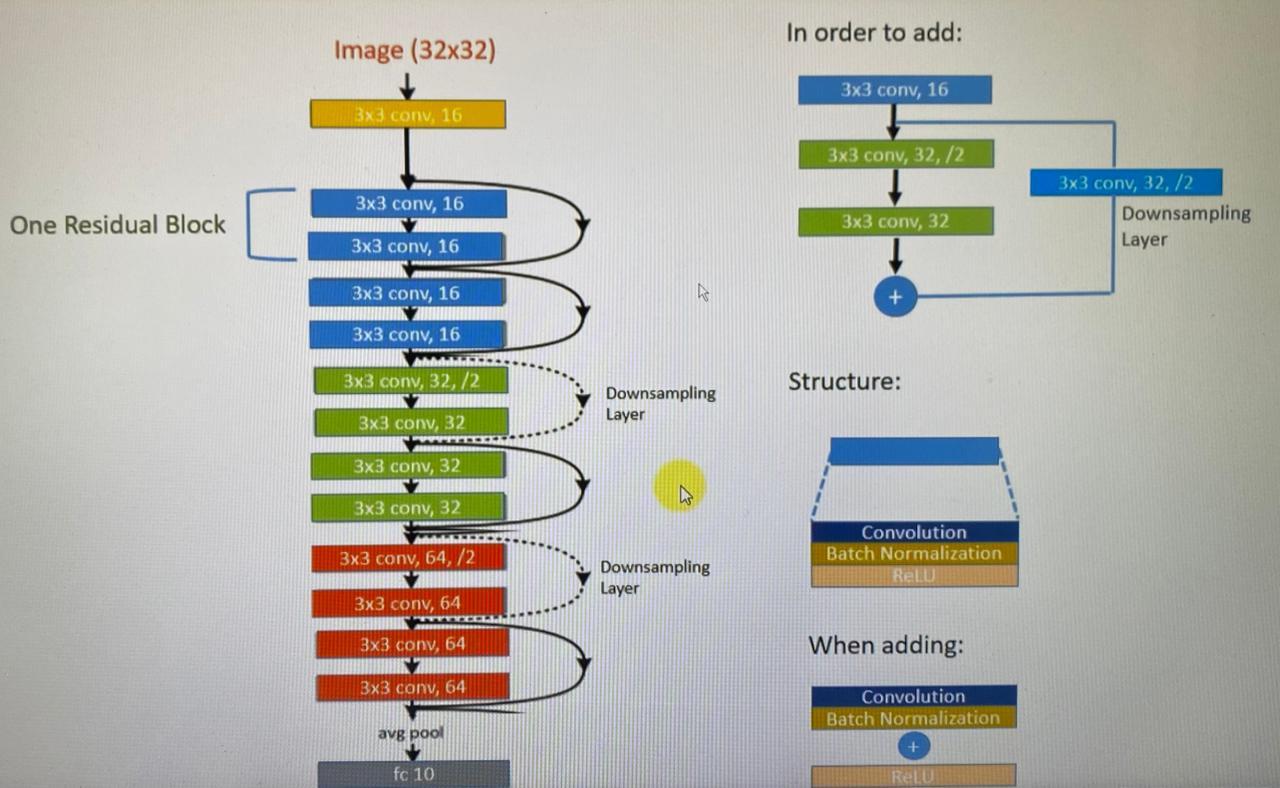

This is the architecture i have followed !!